In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

%cd '/content/drive/MyDrive/ML'

/content/drive/MyDrive/ML


In [ ]:
import os

folder_path = '/content/drive/MyDrive/ML'

def total_files(folder_path):
    num_files = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
    return num_files

train_files_healthy = "/content/drive/MyDrive/ML/Train_Leaf/Healthy-20260331T090534Z-3-001"
train_files_powdery = "/content/drive/MyDrive/ML/Train_Leaf/Powdery"
train_files_rust = "/content/drive/MyDrive/ML/Train_Leaf/Rust-20260331T083834Z-3-001"

test_files_healthy = "/content/drive/MyDrive/ML/Test_Leaf/Healthy"
test_files_powdery = "/content/drive/MyDrive/ML/Test_Leaf/Powdery"
test_files_rust = "/content/drive/MyDrive/ML/Test_Leaf/Rust"


valid_files_healthy = "/content/drive/MyDrive/ML/Validation_Leaf/Healthy"
valid_files_powdery = "/content/drive/MyDrive/ML/Validation_Leaf/Powdery"
valid_files_rust = "/content/drive/MyDrive/ML/Validation_Leaf/Rust"

print("Number of healthy leaf images in training set", total_files(train_files_healthy))
print("Number of powder leaf images in training set", total_files(train_files_powdery))
print("Number of rusty leaf images in training set", total_files(train_files_rust))

print("========================================================")

print("Number of healthy leaf images in test set", total_files(test_files_healthy))
print("Number of powder leaf images in test set", total_files(test_files_powdery))
print("Number of rusty leaf images in test set", total_files(test_files_rust))

print("========================================================")

print("Number of healthy leaf images in validation set", total_files(valid_files_healthy))
print("Number of powder leaf images in validation set", total_files(valid_files_powdery))
print("Number of rusty leaf images in validation set", total_files(valid_files_rust))


Number of healthy leaf images in training set 0
Number of powder leaf images in training set 410
Number of rusty leaf images in training set 0
Number of healthy leaf images in test set 50
Number of powder leaf images in test set 50
Number of rusty leaf images in test set 50
Number of healthy leaf images in validation set 20
Number of powder leaf images in validation set 20
Number of rusty leaf images in validation set 20


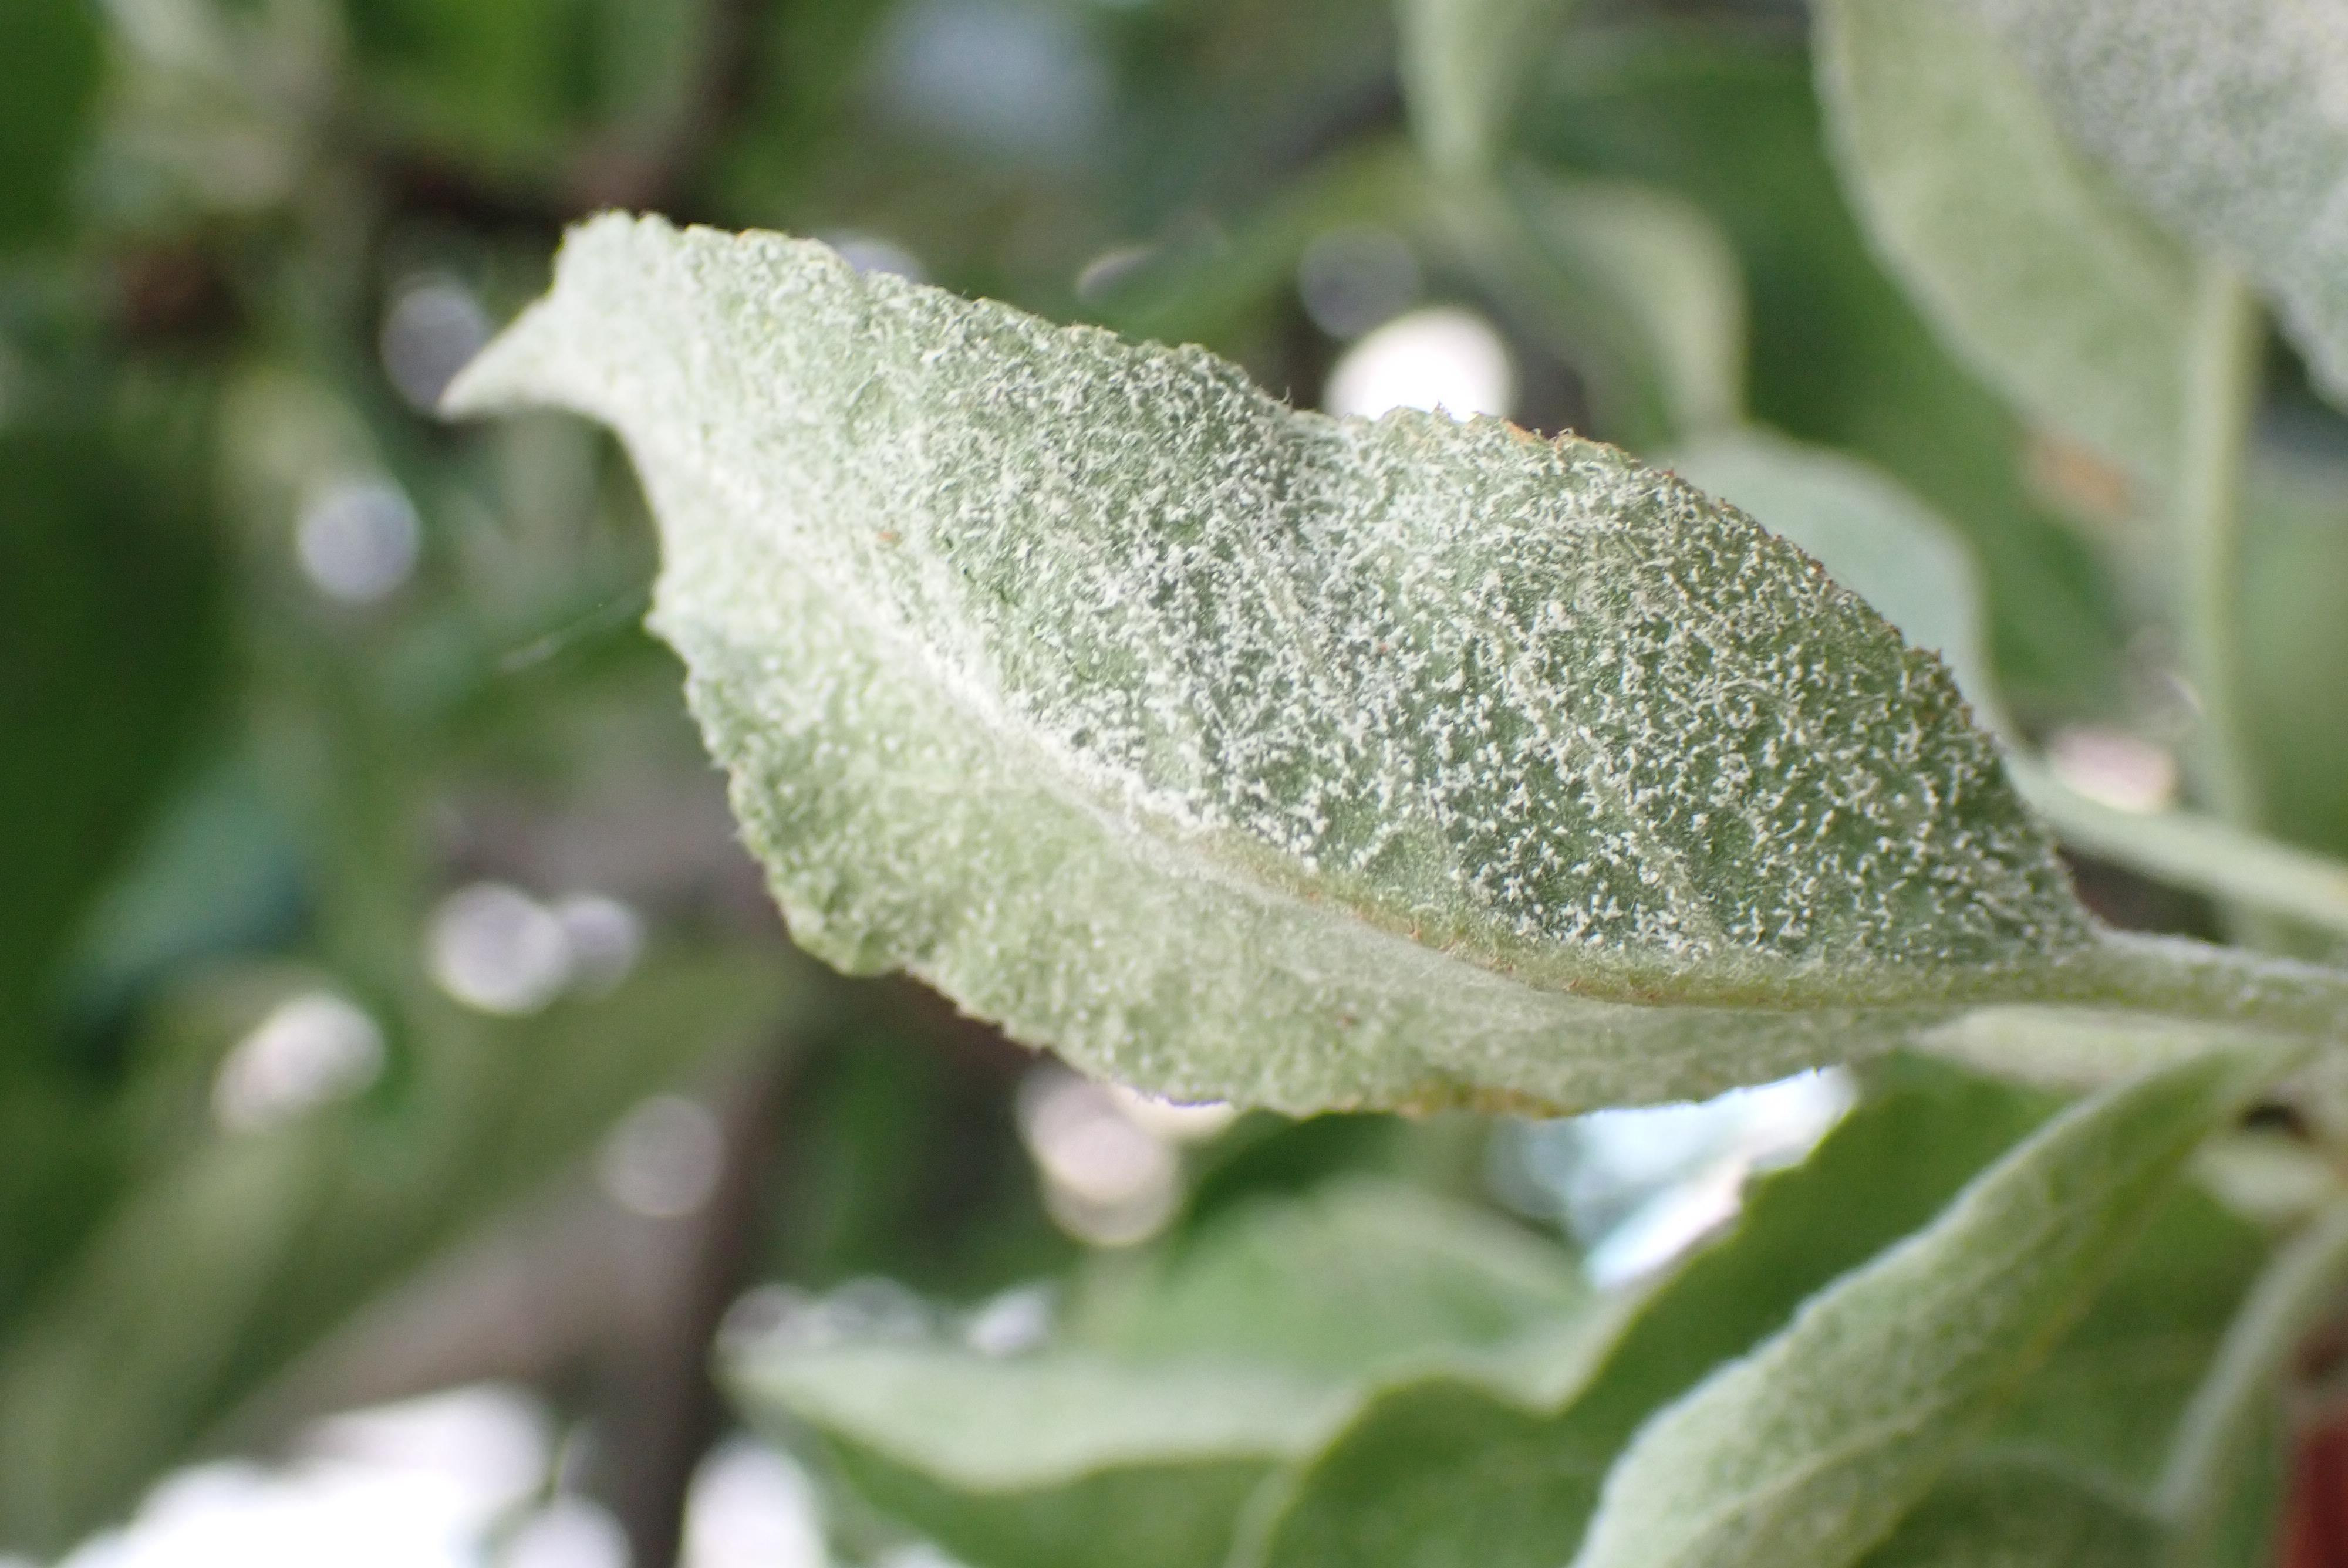

In [ ]:























































































































































from PIL import Image
import IPython.display as display

image_path = '/content/drive/MyDrive/ML/Train_Leaf/Powdery/802f7439ec1ef0cd.jpg'

with open(image_path, 'rb') as f:
    display.display(display.Image(data=f.read(), width=500))

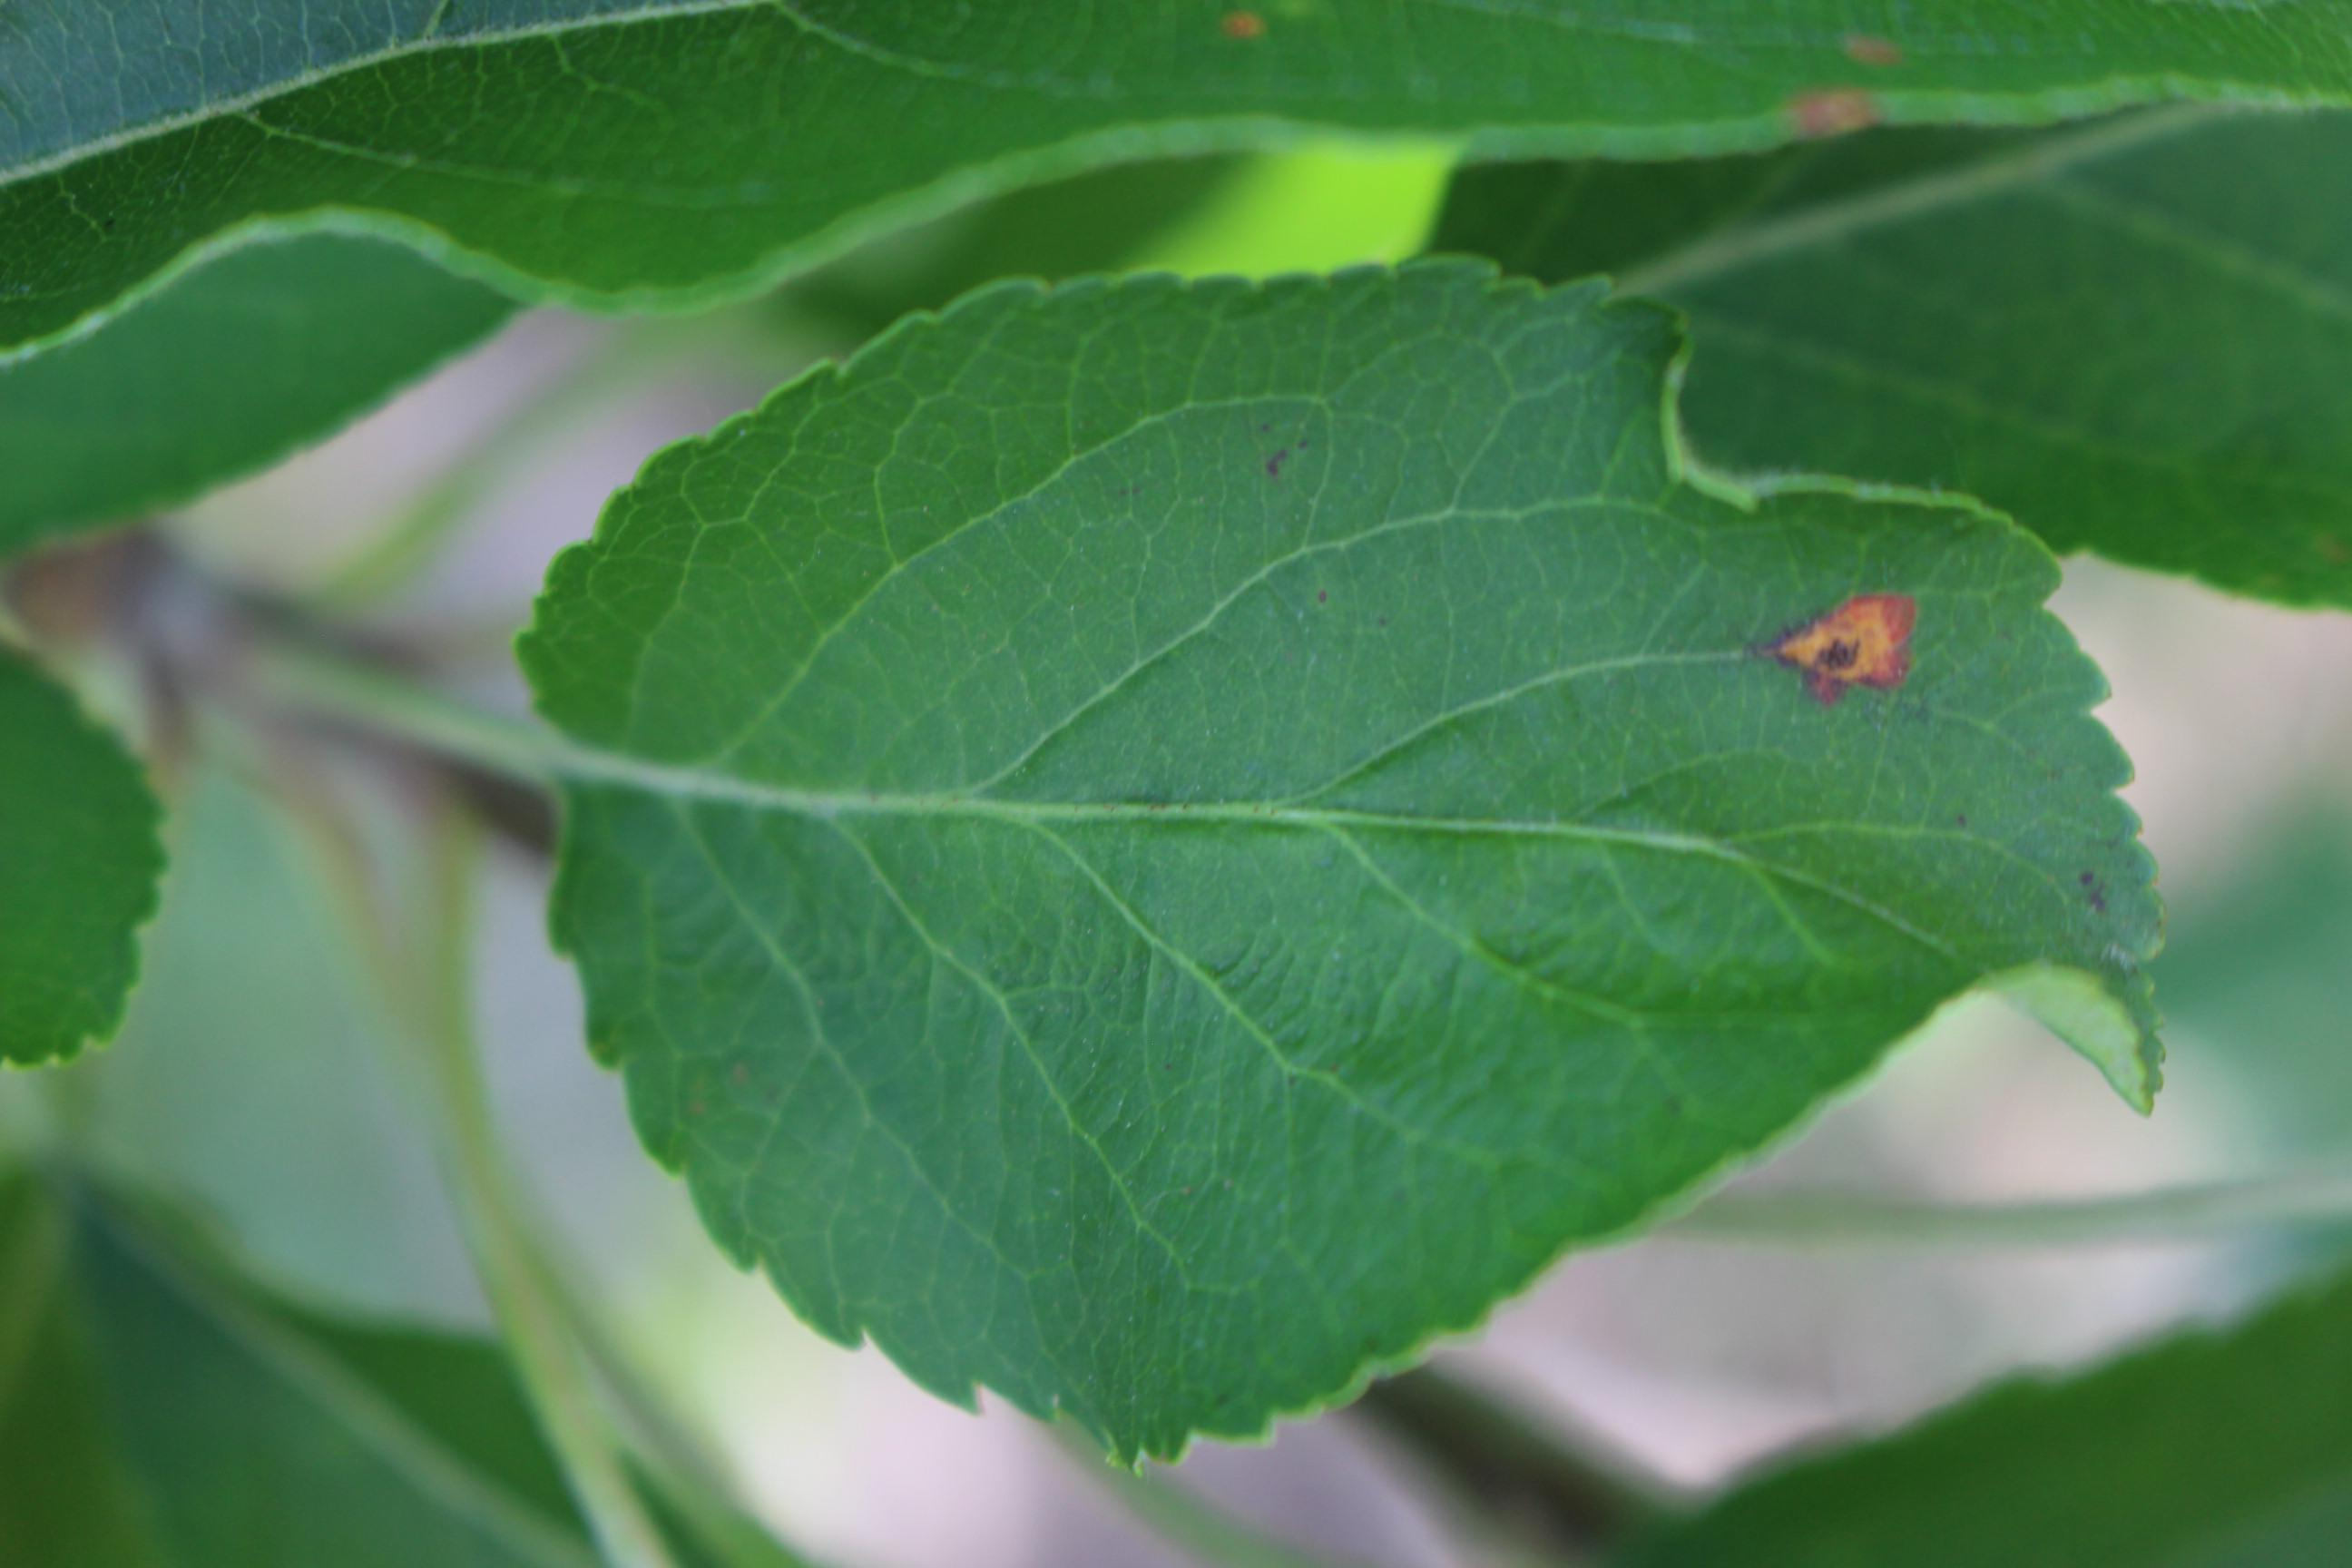

In [ ]:
image_path = '/content/drive/MyDrive/ML/Train_Leaf/Rust-20260331T083834Z-3-001/Rust/807947b90eb77856.jpg'

with open(image_path, 'rb') as f:
    display.display(display.Image(data=f.read(), width=600))

In [ ]:
import tensorflow as tf

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory('/content/drive/MyDrive/ML/Train_Leaf',
                                                    target_size=(225, 225),
                                                    batch_size=32,
                                                    class_mode='categorical')

validation_generator = test_datagen.flow_from_directory('/content/drive/MyDrive/ML/Validation_Leaf',
                                                        target_size=(225, 225),
                                                        batch_size=32,
                                                        class_mode='categorical')

Found 875 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(225, 225, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(train_generator,
                    batch_size=16,
                    epochs=5,
                    validation_data=validation_generator
                    )

Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 172s 6s/step - accuracy: 0.9143 - loss: 0.2218 - val_accuracy: 0.6667 - val_loss: 0.9756
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 151s 5s/step - accuracy: 0.9326 - loss: 0.1752 - val_accuracy: 0.6833 - val_loss: 1.1286
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 153s 5s/step - accuracy: 0.9451 - loss: 0.1381 - val_accuracy: 0.6833 - val_loss: 0.9879
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 146s 5s/step - accuracy: 0.9554 - loss: 0.1265 - val_accuracy: 0.7167 - val_loss: 0.9029
Epoch 5/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 146s 5s/step - accuracy: 0.9577 - loss: 0.1320 - val_accuracy: 0.8833 - val_loss: 0.8285


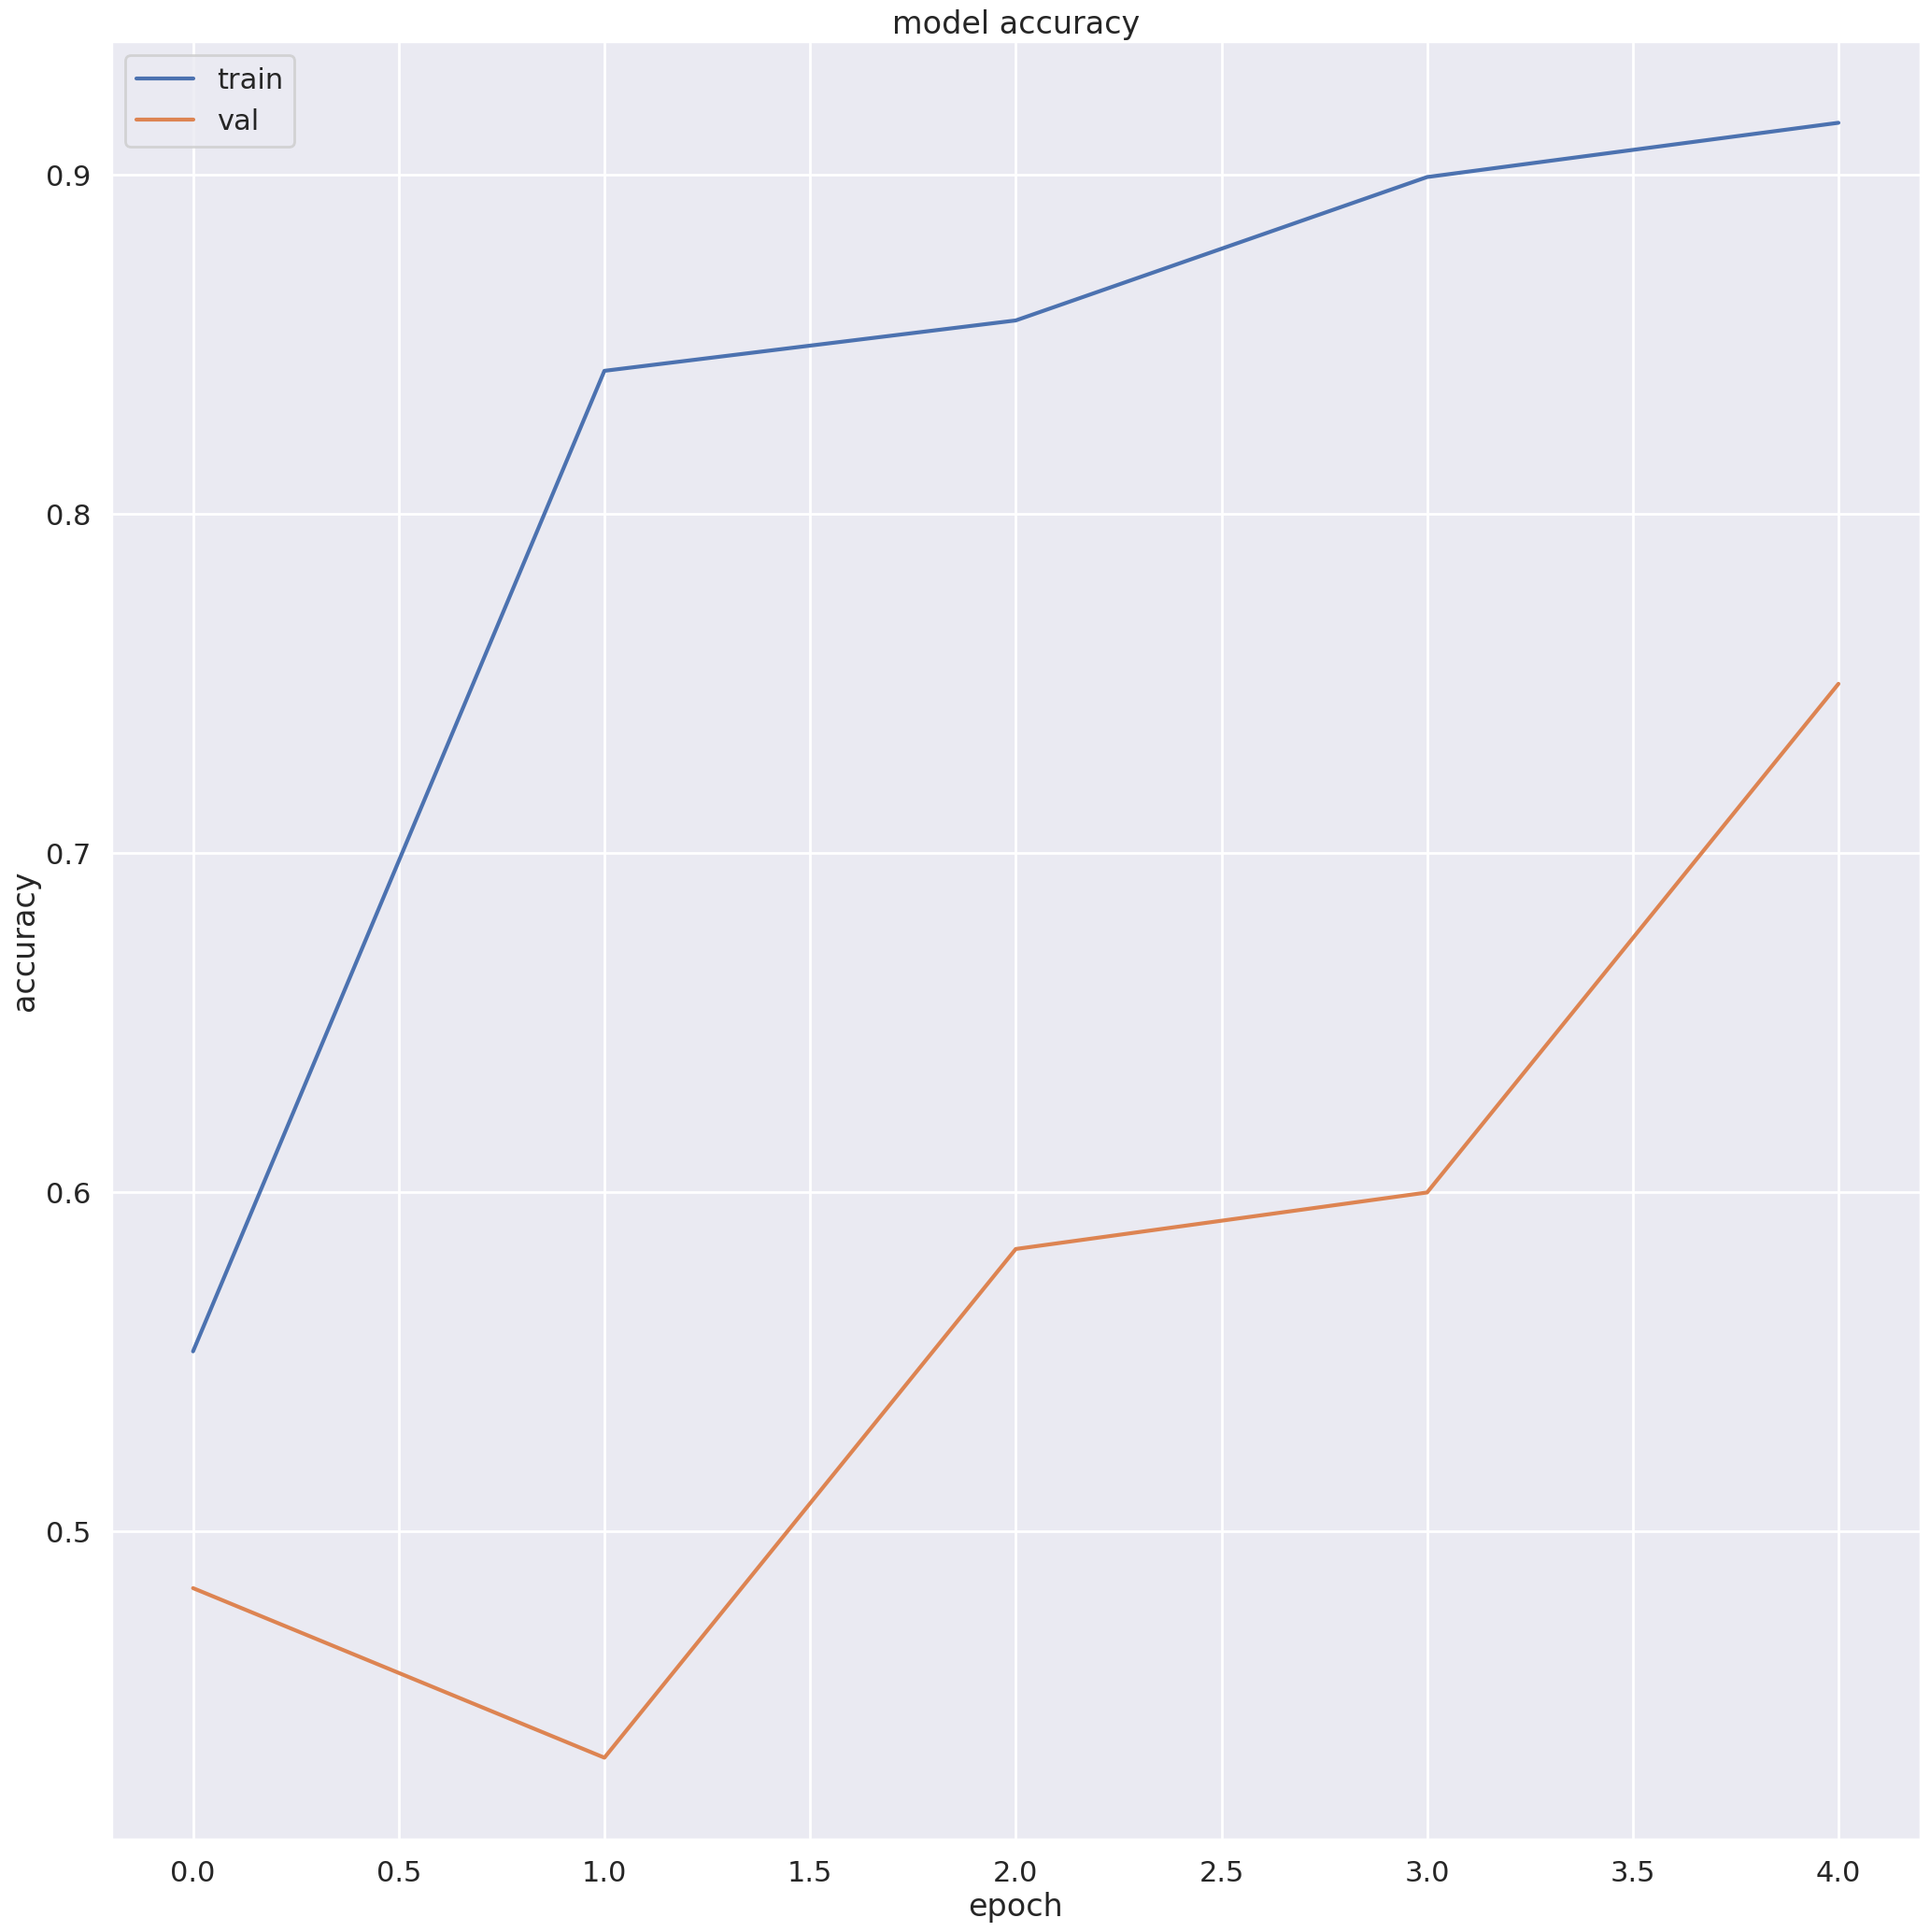

In [ ]:
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure

import seaborn as sns
sns.set_theme()
sns.set_context("poster")

figure(figsize=(25, 25), dpi=100)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

def preprocess_image(image_path, target_size=(225, 225)):
    img = load_img(image_path, target_size=target_size)
    x = img_to_array(img)
    x = x.astype('float32') / 255.
    x = np.expand_dims(x, axis=0)
    return x

x = preprocess_image('/content/drive/MyDrive/ML/Test_Leaf/Rust/99f3639158699cd8.jpg')

In [ ]:
predictions = model.predict(x)
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


array([3.8083821e-05, 3.8615063e-11, 9.9996197e-01], dtype=float32)

In [ ]:
labels = train_generator.class_indices
labels = {v: k for k, v in labels.items()}
labels

{0: 'Healthy-20260331T090534Z-3-001',
 1: 'Powdery',
 2: 'Rust-20260331T083834Z-3-001'}

In [ ]:
predicted_label = labels[np.argmax(predictions)]
print(predicted_label)

Rust-20260331T083834Z-3-001
